# Practical-6

## Ensemble Learning Models in Scikit-Learn

**Name:** Vinit Sindhal

**Enroll no.:** 2503051240126

**Roll no.:** 31

**Division/Batch:** 2B3/2nd  

**Aim:** To implement Random Forest, Gradient Boosting, and Stacking ensemble models and evaluate their performance.

---

Link : https://colab.research.google.com/drive/1hR9UXzOt3DAbXS-DUJMCaNEQFdA2H6e1#scrollTo=hAFEViW64tKS



In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [ ]:
X, y = load_breast_cancer(return_X_y=True)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
rf_pred = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.9707602339181286


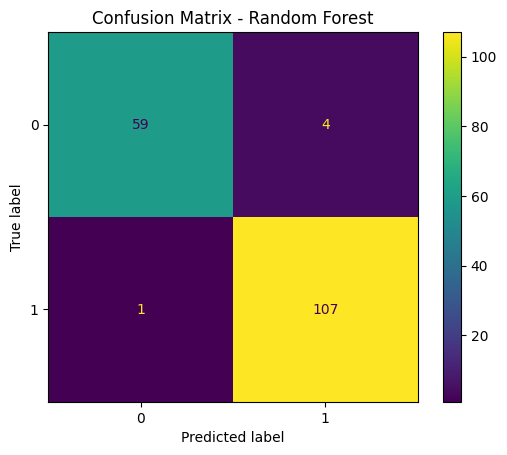

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Random Forest")
plt.show()

In [ ]:
gb_model = GradientBoostingClassifier(n_estimators=100,
learning_rate=0.1)
gb_model.fit(X_train, y_train)

GradientBoostingClassifier()

In [ ]:
gb_pred = gb_model.predict(X_test)
print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb_pred))

Gradient Boosting Accuracy: 0.9590643274853801


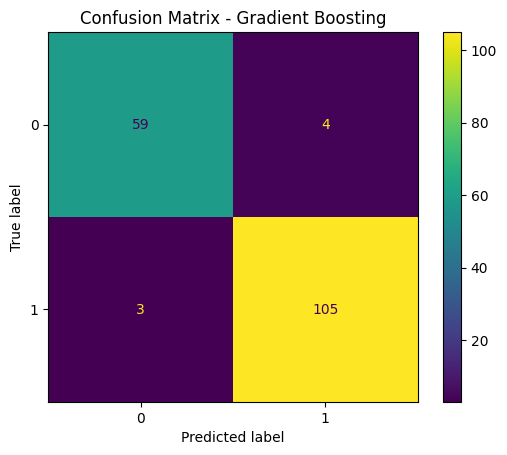

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_gb = confusion_matrix(y_test, gb_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_gb)
disp.plot()

plt.title("Confusion Matrix - Gradient Boosting")
plt.show()

In [ ]:
estimators = [
    ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
    ('svm', SVC(probability=True))
]

In [ ]:
stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

In [ ]:
stack_model.fit(X_train, y_train)
stack_pred = stack_model.predict(X_test)
print("Stacking Model Accuracy:", accuracy_score(y_test, stack_pred))

Stacking Model Accuracy: 0.9707602339181286


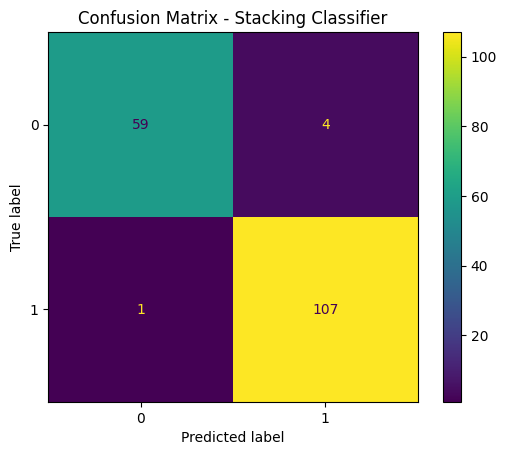

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_stack = confusion_matrix(y_test, stack_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_stack)
disp.plot()

plt.title("Confusion Matrix - Stacking Classifier")
plt.show()

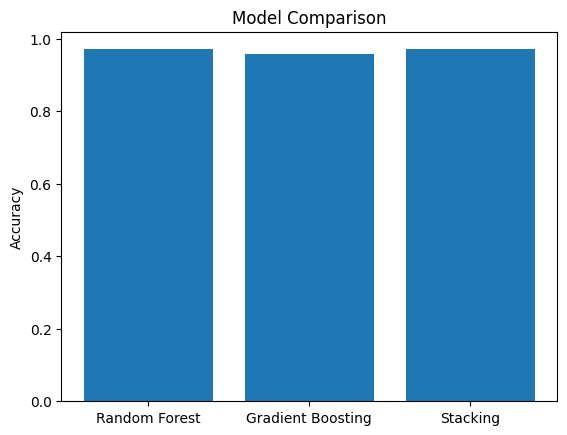

In [ ]:
models = ["Random Forest", "Gradient Boosting", "Stacking"]
accuracies = [
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, gb_pred),
    accuracy_score(y_test, stack_pred)
]

plt.figure()
plt.bar(models, accuracies)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()